In [264]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Loading the data

In [265]:
df = pd.read_csv('24_Coffee_Taste_Test.csv')
df.head()

,submission_id,age,cups,where_drink,brew,brew_other,purchase,purchase_other,favorite,favorite_specify,...,spent_equipment,value_equipment,gender,gender_specify,education_level,ethnicity_race,ethnicity_race_specify,employment_status,number_children,political_affiliation
0,gMR29l,18-24 years old,NaN,NaN,NaN,NaN,NaN,NaN,Regular drip coffee,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,BkPN0e,25-34 years old,NaN,NaN,Pod/capsule machine (e.g. Keurig/Nespresso),NaN,NaN,NaN,Iced coffee,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,W5G8jj,25-34 years old,NaN,NaN,Bean-to-cup machine,NaN,NaN,NaN,Regular drip coffee,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4xWgGr,35-44 years old,NaN,NaN,Coffee brewing machine (e.g. Mr. Coffee),NaN,NaN,NaN,Iced coffee,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,QD27Q8,25-34 years old,NaN,NaN,Pour over,NaN,NaN,NaN,Latte,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Raw data overview
## Shape and Data types
The dataset has 4042 rows and 57 columns of which 13 are floats and 44 are objects.

In [266]:
df.shape

(4042, 57)

In [267]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4042 entries, 0 to 4041
Data columns (total 57 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   submission_id                 4042 non-null   object 
 1   age                           4011 non-null   object 
 2   cups                          3949 non-null   object 
 3   where_drink                   3972 non-null   object 
 4   brew                          3657 non-null   object 
 5   brew_other                    678 non-null    object 
 6   purchase                      710 non-null    object 
 7   purchase_other                31 non-null     object 
 8   favorite                      3980 non-null   object 
 9   favorite_specify              116 non-null    object 
 10  additions                     3959 non-null   object 
 11  additions_other               48 non-null     object 
 12  dairy                         1686 non-null   object 
 13  swe

## Null Counts

In [268]:
df.isnull().sum().sort_values()

submission_id                      0
age                               31
favorite                          62
where_drink                       70
additions                         83
style                             84
cups                              93
roast_level                      102
expertise                        104
caffeine                         125
strength                         126
coffee_a_bitterness              244
coffee_a_personal_preference     253
coffee_b_bitterness              262
coffee_a_acidity                 263
coffee_b_personal_preference     269
prefer_abc                       270
prefer_overall                   272
coffee_b_acidity                 275
coffee_d_bitterness              275
coffee_c_personal_preference     276
coffee_d_acidity                 277
coffee_d_personal_preference     278
coffee_c_bitterness              278
prefer_ad                        281
coffee_c_acidity                 291
brew                             385
w

## Basic Statistics

In [269]:
float_cols = df.select_dtypes(include=["float"]).columns.tolist()
df[float_cols].describe()

,expertise,coffee_a_bitterness,coffee_a_acidity,coffee_a_personal_preference,coffee_b_bitterness,coffee_b_acidity,coffee_b_personal_preference,coffee_c_bitterness,coffee_c_acidity,coffee_c_personal_preference,coffee_d_bitterness,coffee_d_acidity,coffee_d_personal_preference
count,3938.000000,3798.000000,3779.000000,3789.000000,3780.000000,3767.000000,3773.000000,3764.000000,3751.000000,3766.000000,3767.000000,3765.000000,3764.000000
mean,5.693499,2.141127,3.634824,3.310900,3.013228,2.223786,3.068646,3.071998,2.366836,3.064790,2.162729,3.858167,3.375930
std,1.948867,0.947163,0.982113,1.185953,0.992875,0.865389,1.113546,0.999267,0.921048,1.128431,1.081546,1.007973,1.452504
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,5.000000,1.000000,3.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000,3.000000,2.000000
50%,6.000000,2.000000,4.000000,3.000000,3.000000,2.000000,3.000000,3.000000,2.000000,3.000000,2.000000,4.000000,4.000000
75%,7.000000,3.000000,4.000000,4.000000,4.000000,3.000000,4.000000,4.000000,3.000000,4.000000,3.000000,5.000000,5.000000
max,10.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


## Interesting columns
### favorite
This column denotes the subject's favorite type of coffee 

In [270]:
df.favorite.value_counts(dropna=False)

Pourover                            1084
Latte                                680
Regular drip coffee                  442
Cappuccino                           341
Espresso                             330
Cortado                              312
Americano                            249
Iced coffee                          156
Mocha                                118
Other                                114
Cold brew                            109
NaN                                   62
Blended drink (e.g. Frappuccino)      45
Name: favorite, dtype: int64

### gender
This column denotes the subject's gender

In [271]:
df.gender.value_counts(dropna=False)

Male                      2524
Female                     853
NaN                        519
Non-binary                 103
Prefer not to say           33
Other (please specify)      10
Name: gender, dtype: int64

### total_spend
This column denotes the range of money the subject spends on coffee per month

In [272]:
df.total_spend.value_counts(dropna=False)

$20-$40     1293
$40-$60     1050
NaN          531
<$20         427
$60-$80      387
$80-$100     223
>$100        131
Name: total_spend, dtype: int64

## age
This column denotes the age bracket of the subject

In [273]:
df.age.value_counts(dropna=False)


25-34 years old    1986
35-44 years old     960
18-24 years old     461
45-54 years old     302
55-64 years old     187
>65 years old        95
NaN                  31
<18 years old        20
Name: age, dtype: int64

### where_drink
This column denotes where( home, at a cafe etc..) people prefer to drink coffee

In [274]:
df.where_drink.value_counts(dropna=False)

At home                                1625
At home, At a cafe                      416
At home, At the office                  407
At the office, At home                  229
At the office                           141
                                       ... 
At a cafe, At the office, On the go       1
At a cafe, On the go, At the office       1
At home, None of these                    1
On the go, At a cafe, At the office       1
At a cafe, On the go                      1
Name: where_drink, Length: 66, dtype: int64

On initial inspection, the column data seems to be a multiple choice answer on the survey. We can observe some consistent categories here like:
+ At home
+ At a cafe
+ At the office
+ On the go

### wfh
This column denotes whether the subject works from home / office.

In [275]:
df.wfh.value_counts(dropna=False)

I primarily work from home    1592
I primarily work in person    1049
I do a mix of both             883
NaN                            518
Name: wfh, dtype: int64

This column has a lot of missing values, but would be interesting to analyze with the column `where_drink`

### spent_equipment
This column denotes how much a subject has spent on equipment to brew coffee

In [276]:
df.spent_equipment.value_counts(dropna=False)

More than $1,000    780
$100-$300           750
$500-$1000          642
$300-$500           597
NaN                 536
$50-$100            310
Less than $20       239
$20-$50             188
Name: spent_equipment, dtype: int64

### cups
This column denotes the average cups of a coffee a subject drinks in a day.

In [277]:
df.cups.value_counts(dropna=False)

2              1663
1              1277
3               473
Less than 1     348
4               121
NaN              93
More than 4      67
Name: cups, dtype: int64

In [278]:
df.employment_status.value_counts(dropna=False)

Employed full-time    2708
NaN                    623
Student                221
Employed part-time     201
Unemployed             126
Retired                 85
Homemaker               78
Name: employment_status, dtype: int64

In [279]:
df[df["wfh"].isna() & df["employment_status"].notna()][["wfh", "employment_status"]]

,wfh,employment_status
133,NaN,Employed full-time
197,NaN,Unemployed
360,NaN,Retired
369,NaN,Retired
565,NaN,Student
713,NaN,Homemaker
800,NaN,Retired
803,NaN,Retired
807,NaN,Student
824,NaN,Employed full-time


To conclude, the data has a lot of missing values, but it does not suffer from inconsistent formatting, outliers or duplicate values. So the only cleaning required is deciding what to do with the missing values

# Cleaning the data

### favorite
This column has only 62 missing values and over 10 categories.<br/> 
It would not make sense to impute a value here, since we cannot be certain what a subject's favorite coffee is.<br/>
Because there are very few missing values, we can safely drop them.

In [280]:
df = df.dropna(subset=["favorite"])
df.favorite.value_counts(dropna=False)

Pourover                            1084
Latte                                680
Regular drip coffee                  442
Cappuccino                           341
Espresso                             330
Cortado                              312
Americano                            249
Iced coffee                          156
Mocha                                118
Other                                114
Cold brew                            109
Blended drink (e.g. Frappuccino)      45
Name: favorite, dtype: int64

### gender
This column has over 500 missing values.<br/>
However, we can reasonably assume that the people who did not specify a gender, preferred not to share their gender. <br/>
So we fill the nan values in this column with `Prefer not to say`

In [281]:
df['gender'] = df['gender'].fillna('Prefer not to say')
df.gender.value_counts(dropna=False)

Male                      2524
Female                     853
Prefer not to say          490
Non-binary                 103
Other (please specify)      10
Name: gender, dtype: int64

### total_spend
For now labelling nans as unknown

In [263]:
df = df.dropna(subset=["total_spend"])
df.total_spend.value_counts(dropna=False)

$20-$40     1293
$40-$60     1049
<$20         426
Unknown      413
$60-$80      387
$80-$100     223
>$100        131
Name: total_spend, dtype: int64

### age
This column has very few missing values, and there is no reliable way to ascertain the age group for a subject, so we drop them.

In [282]:
df = df.dropna(subset=["age"])
df.age.value_counts(dropna=False)

25-34 years old    1971
35-44 years old     954
18-24 years old     448
45-54 years old     299
55-64 years old     184
>65 years old        94
<18 years old        19
Name: age, dtype: int64

### wfh
The category names are very long, so we shorten them to `Work from home`, `Work from office` and `Hybrid`

In [283]:
wfh_mapping = {
    "I primarily work from home": "Work from home",
    "I primarily work in person": "Work from office",
    "I do a mix of both": "Hybrid",
}

# Force Pandas to modify the column safely in place
df.loc[:, "wfh"] = df["wfh"].map(wfh_mapping).fillna(df["wfh"])

In [284]:
df.wfh.value_counts(dropna=False)

Work from home      1592
Work from office    1049
Hybrid               883
NaN                  445
Name: wfh, dtype: int64

This column has a significant amount of missing values.<br/>
We can impute some values using the `employment_status` column

In [285]:
df.employment_status.value_counts(dropna=False)

Employed full-time    2708
NaN                    550
Student                221
Employed part-time     201
Unemployed             126
Retired                 85
Homemaker               78
Name: employment_status, dtype: int64

We can assume that people who have `employment_status` value as `Unemployed`, `Retired`, `Student` do not work so we can create a new status for them as `Unemployed`.<br/>
People with the `Homemaker` status are assumed to be working from home.

In [286]:
# 1. Fill Unemployed, Retired, and Students as 'Unemployed'
df.loc[
    df["wfh"].isna()
    & df["employment_status"].isin(["Unemployed", "Retired", "Student"]),
    "wfh",
] = "Unemployed"

# 2. Fill Homemakers as 'Work from home'
df.loc[df["wfh"].isna() & (df["employment_status"] == "Homemaker"), "wfh"] = (
    "Work from home"
)

df.wfh.value_counts(dropna=False)

Work from home      1600
Work from office    1049
Hybrid               883
NaN                  396
Unemployed            41
Name: wfh, dtype: int64

In [287]:
# For now fill nan as Unknown
df = df.dropna(subset=["wfh"])
df.wfh.value_counts(dropna=False)

Work from home      1600
Work from office    1049
Hybrid               883
Unemployed            41
Name: wfh, dtype: int64

### spent_equipment

In [288]:
df = df.dropna(subset=["spent_equipment"])
df.spent_equipment.value_counts(dropna=False)

More than $1,000    775
$100-$300           748
$500-$1000          641
$300-$500           594
$50-$100            309
Less than $20       239
$20-$50             188
Name: spent_equipment, dtype: int64

### cups

In [289]:
df = df.dropna(subset=["cups"])
df.cups.value_counts(dropna=False)

2              1471
1              1150
3               410
Less than 1     298
4               109
More than 4      56
Name: cups, dtype: int64

In [290]:
new_df = df[['favorite', 'gender', 'total_spend', 'age', 'wfh', 'spent_equipment', 'cups']]
new_df.head()

,favorite,gender,total_spend,age,wfh,spent_equipment,cups
34,Regular drip coffee,Male,$20-$40,45-54 years old,Work from home,$500-$1000,2
41,Pourover,Male,$40-$60,25-34 years old,Hybrid,$50-$100,2
42,Iced coffee,Male,$20-$40,35-44 years old,Work from office,$100-$300,1
43,Pourover,Male,$40-$60,45-54 years old,Work from home,$300-$500,More than 4
46,Cappuccino,Male,$60-$80,35-44 years old,Hybrid,"More than $1,000",2


In [291]:
new_df.shape

(3494, 7)

# Visualizations 


In [292]:
pd.crosstab(new_df["wfh"], new_df["spent_equipment"], normalize="index") * 100


spent_equipment,$100-$300,$20-$50,$300-$500,$50-$100,$500-$1000,Less than $20,"More than $1,000"
wfh,,,,,,,
Hybrid,23.644752,5.074971,16.147636,9.227220,19.492503,5.536332,20.876586
Unemployed,28.947368,2.631579,10.526316,7.894737,21.052632,21.052632,7.894737
Work from home,20.396419,5.242967,17.966752,7.097187,17.966752,5.690537,25.639386
Work from office,20.780488,5.951220,16.487805,11.219512,17.853659,9.170732,18.536585


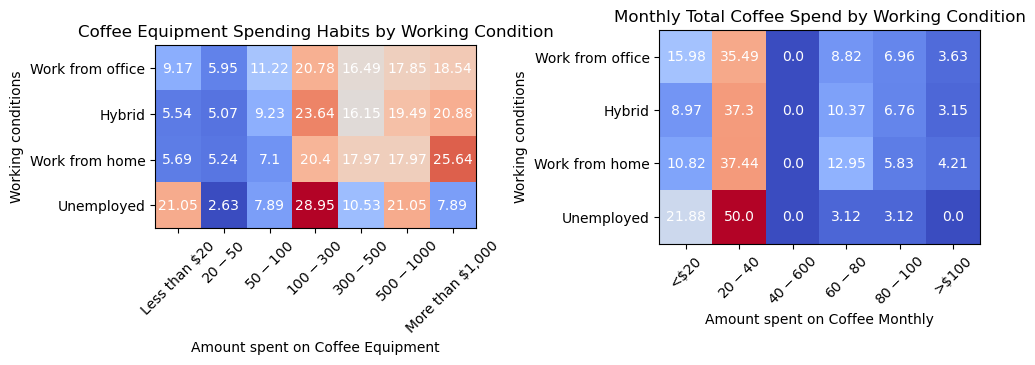

In [333]:
# https://matplotlib.org/stable/gallery/images_contours_and_fields/image_annotated_heatmap.html
spending_order = [
    "Less than $20",
    "$20-$50",
    "$50-$100",
    "$100-$300",
    "$300-$500",
    "$500-$1000",
    "More than $1,000",
]

wfh_order = ["Work from office", "Hybrid", "Work from home", "Unemployed"]

# Since there is a huge gap between category counts, we normalize data across the row
# This makes data proportional (between 0% - 100%) across the rows, reducing skew
heatmap_data = (
    pd.crosstab(new_df["wfh"], new_df["spent_equipment"], normalize="index") * 100
)

heatmap_data = (
    heatmap_data.reindex(index=wfh_order, columns=spending_order).fillna(0).to_numpy()
)
heatmap_data = np.round(heatmap_data, decimals=2)

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))
im = ax[0].imshow(heatmap_data, cmap="coolwarm")
# Show all ticks and label them with the respective list entries
ax[0].set_xticks(range(len(spending_order)), labels=spending_order, rotation=45)
ax[0].set_yticks(range(len(wfh_order)), labels=wfh_order)

# Create colorbar
#cbar = ax[1].figure.colorbar(im, ax=ax)
#cbar.ax.set_ylabel("", rotation=-90, va="bottom")

#Loop over data dimensions and create text annotations.
for i in range(len(wfh_order)):
    for j in range(len(spending_order)):
        text = ax[0].text(j, i, heatmap_data[i, j],
                       ha="center", va="center", color="w")

ax[0].set_title("Coffee Equipment Spending Habits by Working Condition")
ax[0].set_xlabel('Amount spent on Coffee Equipment')
ax[0].set_ylabel('Working conditions')

# Second heatmap
total_spend_order = [
    "<$20",
    "$20-$40",
    "$40-$600",
    "$60-$80",
    "$80-$100",
    ">$100"
]

# Since there is a huge gap between category counts, we normalize data across the row
# This makes data proportional (between 0% - 100%) across the rows, reducing skew
other_heatmap_data = (
    pd.crosstab(new_df["wfh"], new_df["total_spend"], normalize="index") * 100
)

other_heatmap_data = other_heatmap_data.reindex(
    index=wfh_order, columns=total_spend_order
).fillna(0).to_numpy()
other_heatmap_data = np.round(other_heatmap_data, decimals=2)

im = ax[1].imshow(other_heatmap_data, cmap="coolwarm")
# Show all ticks and label them with the respective list entries
ax[1].set_xticks(range(len(total_spend_order)), labels=total_spend_order, rotation=45)
ax[1].set_yticks(range(len(wfh_order)), labels=wfh_order)

# Loop over data dimensions and create text annotations.
for i in range(len(wfh_order)):
    for j in range(len(total_spend_order)):
        text = ax[1].text(
            j, i, other_heatmap_data[i, j], ha="center", va="center", color="w"
        )

ax[1].set_title("Monthly Total Coffee Spend by Working Condition")
ax[1].set_xlabel("Amount spent on Coffee Monthly")
ax[1].set_ylabel("Working conditions")
fig.tight_layout()
plt.show()

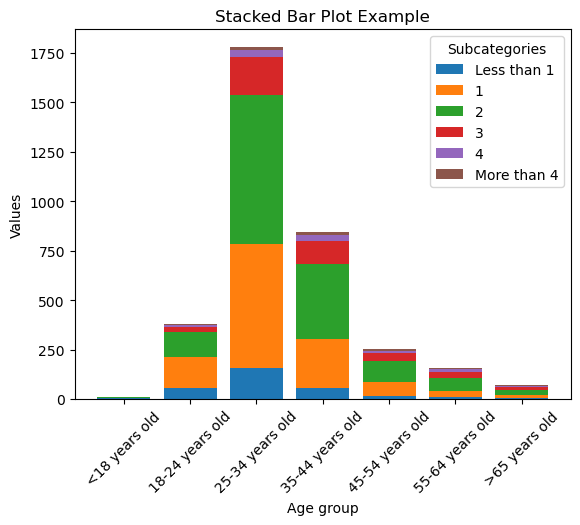

In [ ]:
age_order = [
    "<18 years old",
    "18-24 years old",
    "25-34 years old",
    "35-44 years old",
    "45-54 years old",
    "55-64 years old",
    ">65 years old"
]

cups_order = [
    "Less than 1",
    "1",
    "2",
    "3",
    "4",
    "More than 4"
]

values = new_df.groupby(by=["age", "cups"])[['age', 'cups']].value_counts()
#new_index = pd.MultiIndex.from_product(
#    [age_order, cups_order], names=["Age group", "Daily cups of coffee"]
#)
#values = values.reindex(new_index).fillna(0).to_numpy().reshape((7,6))
values = pd.crosstab(new_df["age"], new_df["cups"])
values = values.reindex(index=age_order, columns=cups_order).fillna(0).to_numpy()

fig, ax = plt.subplots()
ax.set_xticks(range(len(age_order)), labels=age_order, rotation=45)
#ax.set_yticks(range(len(cups_order)), labels=cups_order)
bottom_values = np.zeros(len(age_order))

for i, subcategory in enumerate(cups_order):
    ax.bar(age_order, values[:, i], bottom=bottom_values, label=subcategory)
    bottom_values += values[:, i]

ax.set_ylabel("Values")
ax.set_xlabel('Age group')
ax.set_title("Coffee Drinkers by Age & Volume")
ax.legend(title="Subcategories")

plt.show()

In [336]:
values = new_df.groupby(by=["age", "cups"])[["age", "cups"]].value_counts()
new_index = pd.MultiIndex.from_product(
    [age_order, cups_order], names=["Age group", "Daily cups of coffee"]
)
# values = values.reindex(new_index).fillna(0).to_numpy().reshape((7,6))
values.reindex(new_index).fillna(0).reset_index(name='Count')


,Age group,Daily cups of coffee,Count
0,<18 years old,Less than 1,4.0
1,<18 years old,1,3.0
2,<18 years old,2,5.0
3,<18 years old,3,0.0
4,<18 years old,4,0.0
5,<18 years old,More than 4,0.0
6,18-24 years old,Less than 1,56.0
7,18-24 years old,1,154.0
8,18-24 years old,2,131.0
9,18-24 years old,3,23.0


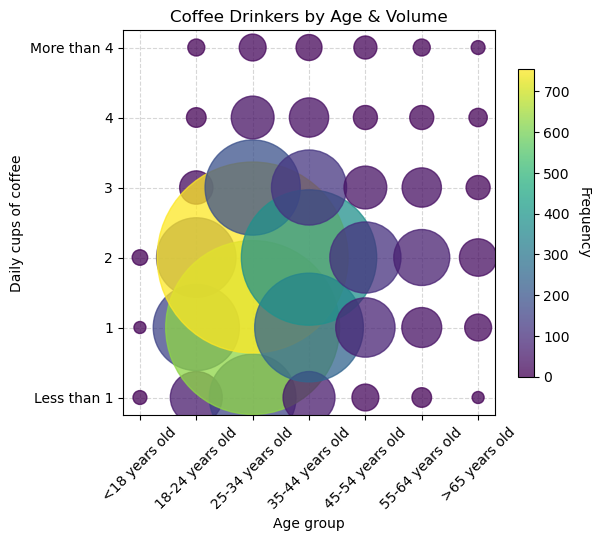

In [341]:
values = new_df.groupby(by=["age", "cups"])[["age", "cups"]].value_counts()
new_index = pd.MultiIndex.from_product(
   [age_order, cups_order], names=["Age group", "Daily cups of coffee"] 
)
# values = values.reindex(new_index).fillna(0).to_numpy().reshape((7,6))
values = values.reindex(new_index).fillna(0).reset_index(name="Count")

fig, ax = plt.subplots(figsize=(6, 5))

bubble = ax.scatter(
    x=values["Age group"],
    y=values["Daily cups of coffee"],
    s=values["Count"] * 25,  # Control marker size (area)
    c=values["Count"],  # Map bubble color to values
    cmap="viridis",
    alpha=0.75,  # Blend overlapping markers
    #edgecolors="black",
)

# 4. Add details and colorbar
ax.set_xticks(range(len(age_order)), labels=age_order, rotation=45)
ax.set_title("Coffee Drinkers by Age & Volume")
ax.set_xlabel("Age group")
ax.set_ylabel("Daily cups of coffee")
ax.grid(True, linestyle="--", alpha=0.5, zorder=0)
ax.set_axisbelow(True)  # Move gridlines behind the bubbles

# Add colorbar indicator
cbar = fig.colorbar(bubble, ax=ax, shrink=0.8)
cbar.set_label("Frequency", rotation=270, labelpad=15)

plt.show()

# Ignore

In [ ]:
df.additions.value_counts(dropna=False)


No - just black                                                                                         2154
Milk, dairy alternative, or coffee creamer                                                               772
No - just black, Milk, dairy alternative, or coffee creamer                                              273
Milk, dairy alternative, or coffee creamer, Sugar or sweetener                                           272
NaN                                                                                                       83
Milk, dairy alternative, or coffee creamer, Flavor syrup                                                  76
Milk, dairy alternative, or coffee creamer, No - just black                                               69
Milk, dairy alternative, or coffee creamer, Sugar or sweetener, Flavor syrup                              57
Sugar or sweetener                                                                                        50
Sugar or sweetener,

In [ ]:
def explode_col(df, column_name: str):
    # 1. Force everything to string, split, and explode
    df[column_name] = df[column_name].astype(str).str.split(r"\s*,\s*")
    df = df.explode(column_name)

    # 2. Convert literal 'nan' strings back to actual NaNs
    df[column_name] = df[column_name].replace("nan", np.nan)
    return df

where_drink_exploded_df = explode_col(df, "where_drink")

In [67]:
where_drink_exploded_df.shape

(7055, 57)

In [68]:
where_drink_exploded_df.where_drink.value_counts(dropna=False)

At home          3644
At the office    1430
At a cafe        1170
On the go         705
NaN                70
None of these      36
Name: where_drink, dtype: int64

In [91]:
df.wfh.value_counts(dropna=False)

I primarily work from home    1592
I primarily work in person    1049
I do a mix of both             883
Not specified                  518
Name: wfh, dtype: int64

In [83]:
place_df = where_drink_exploded_df.groupby(by=["wfh", "where_drink"], as_index=False)[
    ["wfh", "where_drink"]
].value_counts()

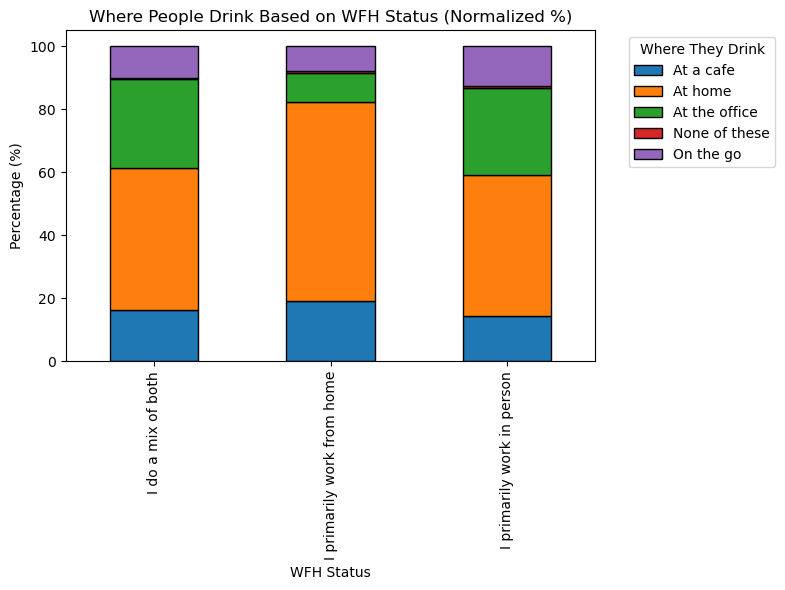

In [ ]:

place_df = where_drink_exploded_df.groupby(by=["wfh", "where_drink"], as_index=False)[
    ["wfh", "where_drink"]
].value_counts()

place_df["percentage"] = place_df.groupby("wfh")["count"].transform(
    lambda x: (x / x.sum()) * 100
)

plot_data = place_df.pivot(index="wfh", columns="where_drink", values="percentage")

plot_data.plot(kind="bar", stacked=True, figsize=(8, 6), edgecolor="black")

plt.title("Where People Drink Based on WFH Status (Normalized %)")
plt.ylabel("Percentage (%)")
plt.xlabel("WFH Status")
plt.legend(title="Where They Drink", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()
